Lambda School Data Science

*Unit 2, Sprint 2, Module 1*

---

# Decision Trees

## Assignment
- [x] [Sign up for a Kaggle account](https://www.kaggle.com/), if you don’t already have one. Go to our Kaggle InClass competition website. You will be given the URL in Slack. Go to the Rules page. Accept the rules of the competition. Notice that the Rules page also has instructions for the Submission process. The Data page has feature definitions.
- [x] Do train/validate/test split with the Tanzania Waterpumps data.
- [x] Begin with baselines for classification.
- [x] Select features. Use a scikit-learn pipeline to encode categoricals, impute missing values, and fit a decision tree classifier.
- [x] Get your validation accuracy score.
- [x] Get and plot your feature importances.
- [ ] Submit your predictions to our Kaggle competition. (Go to our Kaggle InClass competition webpage. Use the blue **Submit Predictions** button to upload your CSV file. Or you can use the Kaggle API to submit your predictions.)
- [ ] Commit your notebook to your fork of the GitHub repo.


## Stretch Goals

### Reading

- A Visual Introduction to Machine Learning
  - [Part 1: A Decision Tree](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/)
  - [Part 2: Bias and Variance](http://www.r2d3.us/visual-intro-to-machine-learning-part-2/)
- [Decision Trees: Advantages & Disadvantages](https://christophm.github.io/interpretable-ml-book/tree.html#advantages-2)
- [How a Russian mathematician constructed a decision tree — by hand — to solve a medical problem](http://fastml.com/how-a-russian-mathematician-constructed-a-decision-tree-by-hand-to-solve-a-medical-problem/)
- [How decision trees work](https://brohrer.github.io/how_decision_trees_work.html)
- [Let’s Write a Decision Tree Classifier from Scratch](https://www.youtube.com/watch?v=LDRbO9a6XPU) — _Don’t worry about understanding the code, just get introduced to the concepts. This 10 minute video has excellent diagrams and explanations._
- [Random Forests for Complete Beginners: The definitive guide to Random Forests and Decision Trees](https://victorzhou.com/blog/intro-to-random-forests/)


### Doing
- [ ] Add your own stretch goal(s) !
- [ ] Define a function to wrangle train, validate, and test sets in the same way. Clean outliers and engineer features. (For example, [what columns have zeros and shouldn't?](https://github.com/Quartz/bad-data-guide#zeros-replace-missing-values) What columns are duplicates, or nearly duplicates? Can you extract the year from date_recorded? Can you engineer new features, such as the number of years from waterpump construction to waterpump inspection?)
- [ ] Try other [scikit-learn imputers](https://scikit-learn.org/stable/modules/impute.html).
- [ ] Make exploratory visualizations and share on Slack.


#### Exploratory visualizations

Visualize the relationships between feature(s) and target. I recommend you do this with your training set, after splitting your data. 

For this problem, you may want to create a new column to represent the target as a number, 0 or 1. For example:

```python
train['functional'] = (train['status_group']=='functional').astype(int)
```



You can try [Seaborn "Categorical estimate" plots](https://seaborn.pydata.org/tutorial/categorical.html) for features with reasonably few unique values. (With too many unique values, the plot is unreadable.)

- Categorical features. (If there are too many unique values, you can replace less frequent values with "OTHER.")
- Numeric features. (If there are too many unique values, you can [bin with pandas cut / qcut functions](https://pandas.pydata.org/pandas-docs/stable/getting_started/basics.html?highlight=qcut#discretization-and-quantiling).)

You can try [Seaborn linear model plots](https://seaborn.pydata.org/tutorial/regression.html) with numeric features. For this classification problem, you may want to use the parameter `logistic=True`, but it can be slow.

You do _not_ need to use Seaborn, but it's nice because it includes confidence intervals to visualize uncertainty.

#### High-cardinality categoricals

This code from a previous assignment demonstrates how to replace less frequent values with 'OTHER'

```python
# Reduce cardinality for NEIGHBORHOOD feature ...

# Get a list of the top 10 neighborhoods
top10 = train['NEIGHBORHOOD'].value_counts()[:10].index

# At locations where the neighborhood is NOT in the top 10,
# replace the neighborhood with 'OTHER'
train.loc[~train['NEIGHBORHOOD'].isin(top10), 'NEIGHBORHOOD'] = 'OTHER'
test.loc[~test['NEIGHBORHOOD'].isin(top10), 'NEIGHBORHOOD'] = 'OTHER'
```


In [0]:
%%capture
import sys

# If you're on Colab:
if 'google.colab' in sys.modules:
    DATA_PATH = 'https://raw.githubusercontent.com/LambdaSchool/DS-Unit-2-Kaggle-Challenge/master/data/'
    !pip install category_encoders==2.*
    !pip install pandas-profiling==2.*

# If you're working locally:
else:
    DATA_PATH = '../data/'

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

train = pd.merge(pd.read_csv(DATA_PATH+'waterpumps/train_features.csv'), 
                 pd.read_csv(DATA_PATH+'waterpumps/train_labels.csv'))
test = pd.read_csv(DATA_PATH+'waterpumps/test_features.csv')
sample_submission = pd.read_csv(DATA_PATH+'waterpumps/sample_submission.csv')

train.shape, test.shape

((59400, 41), (14358, 40))

In [3]:
# Do train/validate/test split with the Tanzania Waterpumps data.
train, val = train_test_split(train)
train.shape, val.shape

((44550, 41), (14850, 41))

In [4]:
# starting with mode baseline, what is the mode of target
train['status_group'].value_counts()

functional                 24173
non functional             17089
functional needs repair     3288
Name: status_group, dtype: int64

In [5]:
# mode is functional, so will get baseline with that
from sklearn.metrics import accuracy_score

guess = ['functional'] * len(train)
accuracy_score(guess, train['status_group'])

0.5426038159371492

### Our baseline is 54% accuaracy. 

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
# from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from category_encoders.one_hot import OneHotEncoder

In [23]:
train.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,44550.000000,44550.000000,44550.000000,44550.000000,4.455000e+04,44550.000000,44550.000000,44550.000000,44550.000000,44550.000000
mean,37114.810999,326.411952,667.366061,34.088052,-5.706854e+00,0.424736,15.231246,5.585657,181.129787,1302.182806
std,21459.234821,3246.659975,692.916957,6.559339,2.945056e+00,10.666459,17.497159,9.527108,487.003838,951.154277
min,0.000000,0.000000,-63.000000,0.000000,-1.164838e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18447.250000,0.000000,0.000000,33.098789,-8.538938e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37117.000000,0.000000,367.000000,34.911780,-5.028312e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55670.750000,25.000000,1318.000000,37.189736,-3.326117e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2628.000000,40.344301,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [24]:
train.describe(exclude='number').T.sort_values(by='unique')

,count,unique,top,freq
recorded_by,44550,1,GeoData Consultants Ltd,44550
public_meeting,42035,2,True,38223
permit,42236,2,True,29093
status_group,44550,3,functional,24173
source_class,44550,3,groundwater,34285
quantity_group,44550,5,enough,24833
quantity,44550,5,enough,24833
management_group,44550,5,user-group,39294
quality_group,44550,6,good,38077
waterpoint_type_group,44550,6,communal standpipe,26021


In [0]:
target = 'status_group'

train_features = train.drop([target, 'id'], axis=1)
numeric_features = train_features.select_dtypes(include='number').columns.tolist()
cardinality = train_features.select_dtypes(exclude='number').nunique()
categorical_features = cardinality[cardinality <= 50].index.tolist()
features = numeric_features + categorical_features

In [26]:
len(features)

31

In [0]:
X_train = train[features]
y_train = train[target]
X_val = train[features]
y_val = train[target]

## Hyperparameter notes:

1st (submited):
- min_samples_leaf = 15
- no PCA

`val score: ~82%`
`test score: 77.113%`

2nd (submitted):
- add PCA (all components) to 1st

`val score: ~83.6%`
`test score: 75.121%`

3rd:
- add scaler to 1st

`val score: 81.89%`
`test score: 77.030%`



In [0]:
water_pipeline = Pipeline([ 
                           ('encoder', OneHotEncoder(use_cat_names=True)),
                           ('imputer', SimpleImputer(strategy='mean')),
                           ('scaler', StandardScaler()),
                           ('model',DecisionTreeClassifier(min_samples_leaf=15))
])

In [47]:
from sklearn.model_selection import GridSearchCV

# Parameters of pipelines can be set using ‘__’ separated parameter names:
param_grid = {
    'model__min_samples_leaf': [None, 15],
    'model__max_depth': [None, 12, 15]
}
search = GridSearchCV(water_pipeline, param_grid, n_jobs=-1)
search.fit(X_train, y_train)
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

Best parameter (CV score=0.765):
{'model__max_depth': None, 'model__min_samples_leaf': 15}


In [49]:
water_pipeline.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('encoder',
                 OneHotEncoder(cols=['basin', 'region', 'public_meeting',
                                     'recorded_by', 'scheme_management',
                                     'permit', 'extraction_type',
                                     'extraction_type_group',
                                     'extraction_type_class', 'management',
                                     'management_group', 'payment',
                                     'payment_type', 'water_quality',
                                     'quality_group', 'quantity',
                                     'quantity_group', 'source', 'source_type',
                                     'source_...
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('model',
                 DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                        criterion='gini', max_depth=None,
                

In [50]:
water_pipeline.score(X_val, y_val)

0.8189898989898989

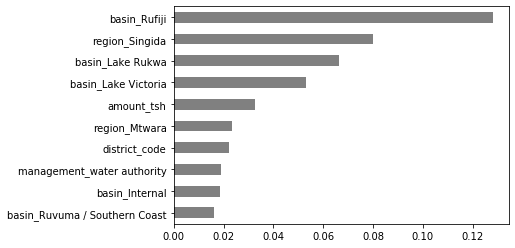

In [14]:
# can't really run this after running PCA (loose interpretability)
import matplotlib.pyplot as plt 
encoder = water_pipeline.named_steps['onehotencoder']
encoded_columns = encoder.transform(X_val).columns
importances = pd.Series(water_pipeline.named_steps['decisiontreeclassifier'].feature_importances_, encoded_columns)
# plt.figure(10, 30)
importances.sort_values()[-10:].plot.barh(color='grey');

In [0]:
X_test = test[features]
y_preds = water_pipeline.predict(X_test)

In [52]:
submission = test[['id']]
submission['status_group'] = pd.Series(y_preds)
submission.head()

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,id,status_group
0,50785,functional
1,51630,functional
2,17168,functional
3,45559,non functional
4,49871,functional


In [0]:
submission.to_csv('submission3.csv', index=False)